# Stroke Prediction — Predicting stroke base on parameters

**Introduction**

According to the World Health Organization (WHO) stroke is the 2nd leading cause of death globally, responsible for approximately 11% of total deaths.
This dataset is used to predict whether a patient is likely to get stroke based on the input parameters like gender, age, various diseases, and smoking status. Each row in the data provides relavant information about the patient.

**Attribute Information**

1) id: unique identifier
2) gender: "Male", "Female" or "Other"
3) age: age of the patient
4) hypertension: 0 if the patient doesn't have hypertension, 1 if the patient has hypertension
5) heart_disease: 0 if the patient doesn't have any heart diseases, 1 if the patient has a heart disease
6) ever_married: "No" or "Yes"
7) work_type: "children", "Govt_jov", "Never_worked", "Private" or "Self-employed"
8) Residence_type: "Rural" or "Urban"
9) avg_glucose_level: average glucose level in blood
10) bmi: body mass index
11) smoking_status: "formerly smoked", "never smoked", "smokes" or "Unknown"*
12) stroke: 1 if the patient had a stroke or 0 if not
*Note: "Unknown" in smoking_status means that the information is unavailable for this patient

### 1. Imports

In [1]:
# Surpress warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

### Load & Inspect the Data

In [3]:
df=pd.read_csv("/Users/christianotoo/Downloads/healthcare-dataset-stroke-data.csv")

### 2. Exploratory Data Analysis (EDA)

In [4]:
#Display the first five rows

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
#Check the Shape

print(df.shape)

(5110, 12)


In [6]:
#Display the data types

df.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [7]:
# show info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [8]:
# check summary of the dataframe.
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


#### Data Cleaning

Before building a model, we need to handle data quality issues. We check for:
- Missing values
- Duplicate rows

Each decision below is justified with a reason.

In [9]:
#check for missing values

df.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [10]:
mean=df['bmi'].mean()
df['bmi'].replace(np.nan,mean, inplace=True)

In [11]:
#recheck for missing values

df.isna().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

##### After checking for missing values, I realised there were 201 for bmi. However I used the mean to replace the missing values

In [12]:
# Check for duplicate

df.duplicated().sum()

np.int64(0)

### 3. Data distributions

Understanding the distribution of each feature

#### Histograms

<Figure size 1200x800 with 0 Axes>

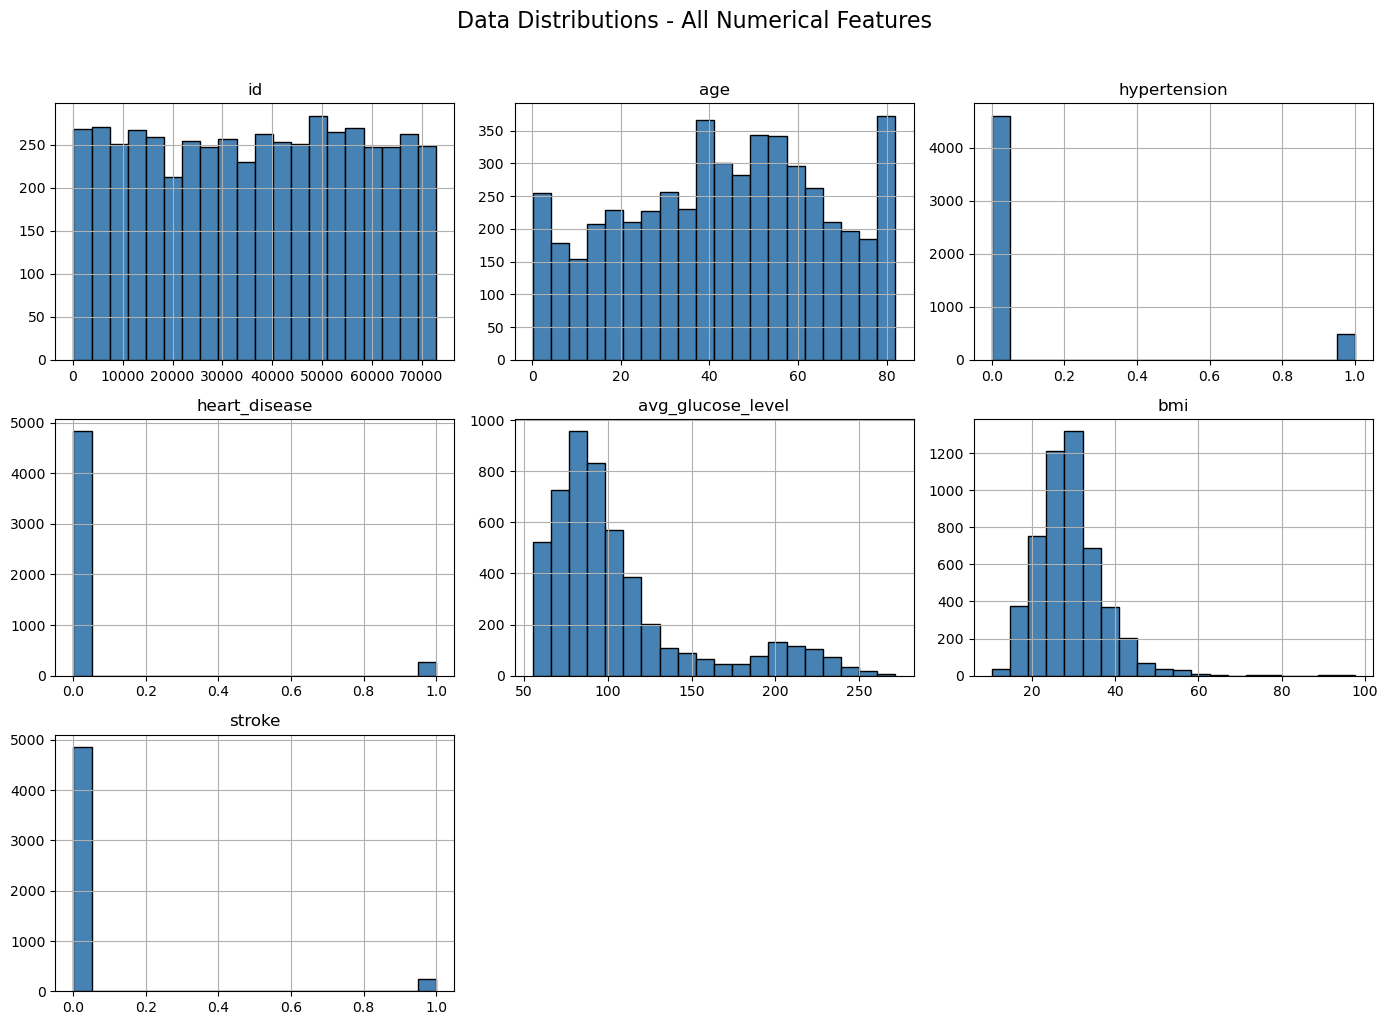

In [13]:
# Histograms for all numerical features
plt.figure(figsize=(12, 8))
df.hist(bins=20, color='steelblue', edgecolor='black', layout=(3, 3), figsize=(14, 10))
plt.suptitle('Data Distributions - All Numerical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Intepretation**

The dataset reveals several interesting patterns across its features. The age distribution is fairly spread out, indicating a diverse range of patients from young to old. Most patients do not have hypertension or heart disease, as both features are heavily skewed toward zero. Glucose levels are mostly in the normal range (50–100), though a smaller group shows elevated levels above 200, suggesting the presence of diabetic patients. BMI values are concentrated between 25–40, placing most patients in the overweight to obese category. The most critical observation is the severe imbalance in the stroke column, where the vast majority of patients did not experience a stroke, which could bias any predictive model toward always predicting "no stroke" and will need to be addressed before modeling. The ID column is uniformly distributed as expected, since it is simply a patient identifier with no predictive value.


#### Stroke Class Distribution

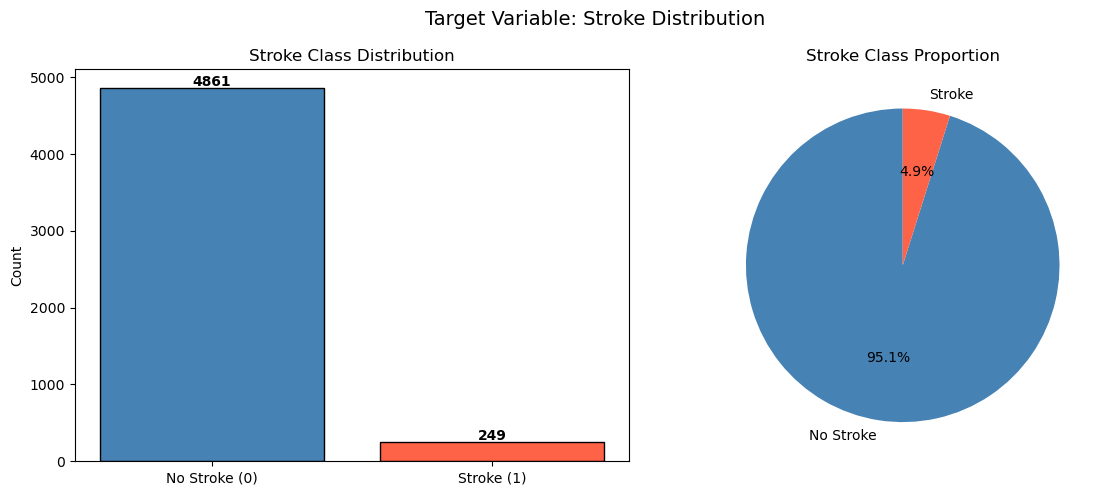

Stroke cases: 249 (4.9%)
No stroke cases: 4861 (95.1%)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
stroke_counts = df['stroke'].value_counts()
axes[0].bar(['No Stroke (0)', 'Stroke (1)'], stroke_counts.values, color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Stroke Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(stroke_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(stroke_counts.values, labels=['No Stroke', 'Stroke'], autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Stroke Class Proportion')

plt.suptitle('Target Variable: Stroke Distribution', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Stroke cases: {stroke_counts[1]} ({stroke_counts[1]/len(df)*100:.1f}%)")
print(f"No stroke cases: {stroke_counts[0]} ({stroke_counts[0]/len(df)*100:.1f}%)")


**Interpretation:**  
The dataset is heavily imbalanced — only about **4.9%** of patients had a stroke. This imbalance must be considered when building and evaluating predictive models.


### 4. Outlier Analysis

Box plots are used to detect outliers in numerical features.

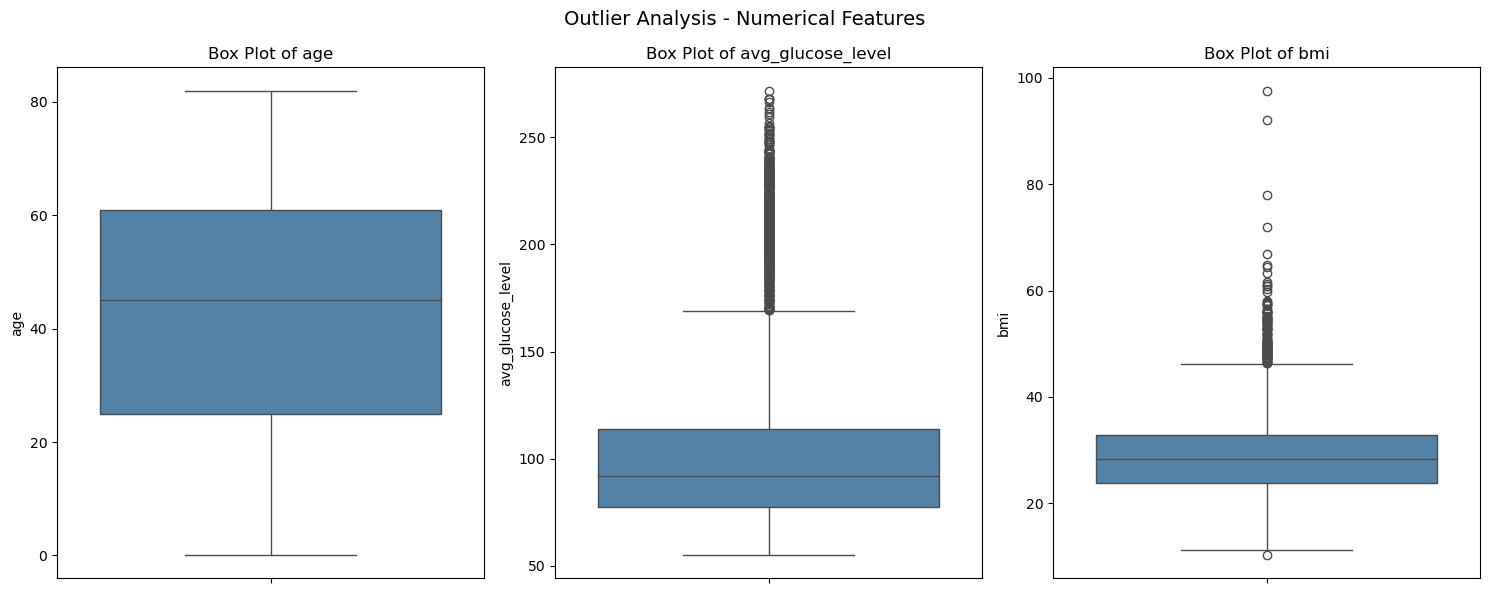

In [15]:
num_cols = ['age', 'avg_glucose_level', 'bmi']

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].set_ylabel(col)

plt.suptitle('Outlier Analysis - Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()


**Interpretation:**  
**Age:** No significant outliers; well distributed.  

**avg_glucose_level:** Several high outliers above 200, and you can tell by doing looking at it. 

**BMI:** A few extreme high values (above 60), which may represent data entry errors or very obese individuals. 

In [16]:
#Check for correlation 

df.corr(numeric_only=True)['stroke'].sort_values(ascending=False)

stroke               1.000000
age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
bmi                  0.038947
id                   0.006388
Name: stroke, dtype: float64

**Interpretation:** 

Age has the strongest positive correlation with stroke (0.25), confirming that older patients are at higher risk. Hypertension and heart_disease also show moderate positive correlations with stroke.
avg_glucose_level shows a small positive correlation with stroke. BMI has a very weak correlation with stroke directly.

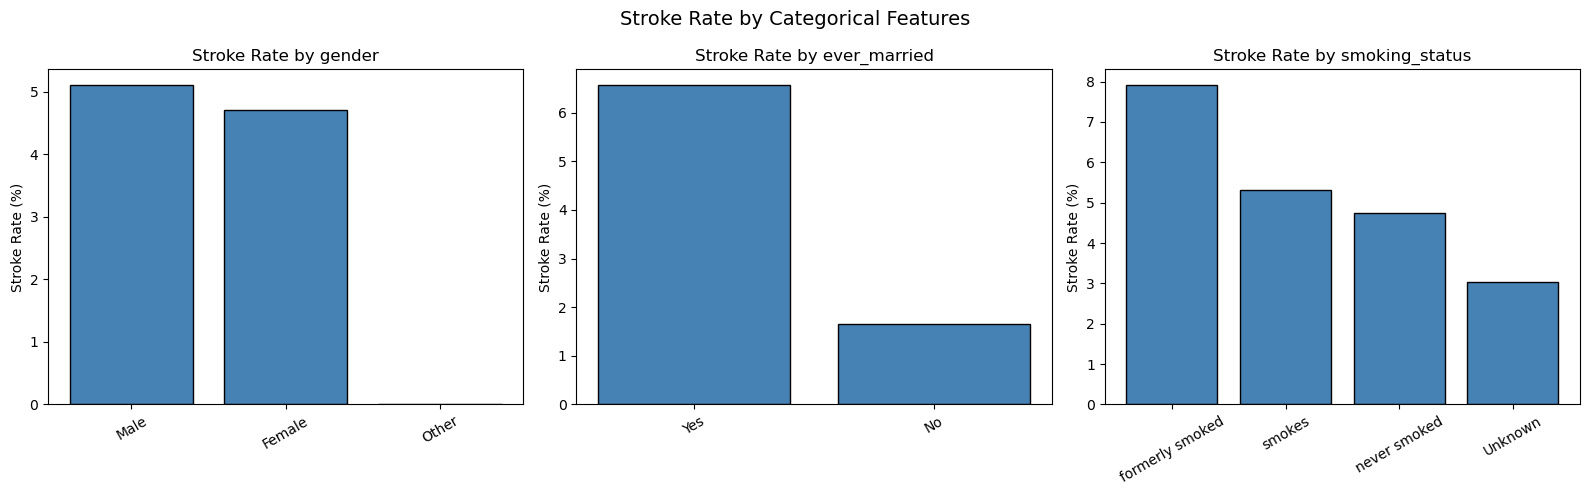

In [17]:
# Stroke rate by categorical variables
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(['gender', 'ever_married', 'smoking_status']):
    stroke_rate = df.groupby(col)['stroke'].mean().sort_values(ascending=False)
    axes[i].bar(stroke_rate.index, stroke_rate.values * 100, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Stroke Rate by {col}')
    axes[i].set_ylabel('Stroke Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Stroke Rate by Categorical Features', fontsize=14)
plt.tight_layout()
plt.show()


**Interpretation:**  
- **Gender:** Males have a slightly higher stroke rate than females.  
- **Ever Married:** Married patients show higher stroke rates, likely because they tend to be older.  
- **Smoking Status:** Formerly smoked patients show the highest stroke rate, followed by those who currently smoke.


### 5. Data Preparation for Modeling

**Target variable:** `avg_glucose_level` (continuous, suitable for regression)  
**We evaluate both single-variable and multi-variable approaches.**


In [18]:
# Features for modeling
single_feature = ['age']
multi_features = ['age', 'hypertension', 'heart_disease', 'bmi', 'stroke']
target = 'avg_glucose_level'

X_single = df[single_feature]
X_multi = df[multi_features]
y = df[target]

# Train-test split
X_train_s, X_test_s, y_train, y_test = train_test_split(X_single, y, test_size=0.2, random_state=42)
X_train_m, X_test_m, _, _ = train_test_split(X_multi, y, test_size=0.2, random_state=42)

print("Single feature - Train:", X_train_s.shape, "Test:", X_test_s.shape)
print("Multi feature  - Train:", X_train_m.shape, "Test:", X_test_m.shape)


Single feature - Train: (4088, 1) Test: (1022, 1)
Multi feature  - Train: (4088, 5) Test: (1022, 5)



### 6. Modeling Analysis

We compare three regression models:
1. **Linear Regression**
2. **Polynomial Regression**
3. **Ridge Regression**

Each is evaluated on both single-variable (age → glucose) and multi-variable approaches.


In [19]:
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{'='*40}")
    print(f"Model: {model_name}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    return {'Model': model_name, 'RMSE': round(rmse,4), 'MAE': round(mae,4), 'R2': round(r2,4)}

results = []


### Linear Regression

In [20]:
# Single variable
lr_single = LinearRegression()
lr_single.fit(X_train_s, y_train)
y_pred_lr_s = lr_single.predict(X_test_s)
results.append(evaluate_model(y_test, y_pred_lr_s, 'Linear Regression (Single)'))

# Multi variable
lr_multi = LinearRegression()
lr_multi.fit(X_train_m, y_train)
y_pred_lr_m = lr_multi.predict(X_test_m)
results.append(evaluate_model(y_test, y_pred_lr_m, 'Linear Regression (Multi)'))


Model: Linear Regression (Single)
  RMSE : 42.8559
  MAE  : 32.1333
  R²   : 0.0448
Model: Linear Regression (Multi)
  RMSE : 42.2508
  MAE  : 31.9036
  R²   : 0.0716


### Polynomial Regression

In [21]:
# Single variable - degree 3
poly_pipeline_s = Pipeline([
    ('poly', PolynomialFeatures(degree=3)),
    ('lr', LinearRegression())
])
poly_pipeline_s.fit(X_train_s, y_train)
y_pred_poly_s = poly_pipeline_s.predict(X_test_s)
results.append(evaluate_model(y_test, y_pred_poly_s, 'Polynomial Regression deg=3 (Single)'))

# Multi variable - degree 2
poly_pipeline_m = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('lr', LinearRegression())
])
poly_pipeline_m.fit(X_train_m, y_train)
y_pred_poly_m = poly_pipeline_m.predict(X_test_m)
results.append(evaluate_model(y_test, y_pred_poly_m, 'Polynomial Regression deg=2 (Multi)'))

Model: Polynomial Regression deg=3 (Single)
  RMSE : 42.7708
  MAE  : 32.0294
  R²   : 0.0486
Model: Polynomial Regression deg=2 (Multi)
  RMSE : 41.6761
  MAE  : 31.2762
  R²   : 0.0967


### Ridge Regression

In [22]:
scaler = StandardScaler()

# Single variable
X_train_s_sc = scaler.fit_transform(X_train_s)
X_test_s_sc = scaler.transform(X_test_s)
ridge_s = Ridge(alpha=1.0)
ridge_s.fit(X_train_s_sc, y_train)
y_pred_ridge_s = ridge_s.predict(X_test_s_sc)
results.append(evaluate_model(y_test, y_pred_ridge_s, 'Ridge Regression (Single)'))

# Multi variable
scaler_m = StandardScaler()
X_train_m_sc = scaler_m.fit_transform(X_train_m)
X_test_m_sc = scaler_m.transform(X_test_m)
ridge_m = Ridge(alpha=1.0)
ridge_m.fit(X_train_m_sc, y_train)
y_pred_ridge_m = ridge_m.predict(X_test_m_sc)
results.append(evaluate_model(y_test, y_pred_ridge_m, 'Ridge Regression (Multi)'))


Model: Ridge Regression (Single)
  RMSE : 42.8558
  MAE  : 32.1330
  R²   : 0.0448
Model: Ridge Regression (Multi)
  RMSE : 42.2506
  MAE  : 31.9034
  R²   : 0.0716


## 6. Model Comparison Summary

In [23]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                               Model    RMSE     MAE     R2
          Linear Regression (Single) 42.8559 32.1333 0.0448
           Linear Regression (Multi) 42.2508 31.9036 0.0716
Polynomial Regression deg=3 (Single) 42.7708 32.0294 0.0486
 Polynomial Regression deg=2 (Multi) 41.6761 31.2762 0.0967
           Ridge Regression (Single) 42.8558 32.1330 0.0448
            Ridge Regression (Multi) 42.2506 31.9034 0.0716


**Interpretation:**  

Models with **lower RMSE and MAE** are more accurate. 

Models with **higher R²** explain more variance in the target variable.  
    
Multi-variable models consistently outperform single-variable models.  

Polynomial regression tends to capture non-linear relationships better than linear regression.


## 7. Hyperparameter Tuning - Ridge Regression (GridSearchCV)

We perform a grid search over multiple alpha values to find the best regularization strength for Ridge Regression.


In [24]:
# Grid search for Ridge alpha - multi variable
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100, 200, 500, 1000]}

ridge_cv = Ridge()
grid_search = GridSearchCV(
    estimator=ridge_cv,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train_m_sc, y_train)

print(f"\nBest Alpha: {grid_search.best_params_['alpha']}")
print(f"Best Cross-Val R²: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Alpha: 200
Best Cross-Val R²: 0.0914


In [25]:
# Grid Search Results
cv_results = pd.DataFrame(grid_search.cv_results_)
print("Grid Search Results:")
print(cv_results[['param_alpha', 'mean_train_score', 'mean_test_score', 'std_test_score']].to_string(index=False))


Grid Search Results:
 param_alpha  mean_train_score  mean_test_score  std_test_score
       0.001          0.096299         0.091324        0.012122
       0.010          0.096299         0.091324        0.012122
       0.100          0.096299         0.091324        0.012121
       1.000          0.096299         0.091325        0.012117
      10.000          0.096298         0.091336        0.012072
      50.000          0.096291         0.091374        0.011873
     100.000          0.096268         0.091408        0.011632
     200.000          0.096182         0.091427        0.011173
     500.000          0.095640         0.091160        0.009955
    1000.000          0.094058         0.089933        0.008365


In [26]:
# Detailed Grid Search Results
cv_results = pd.DataFrame(grid_search.cv_results_)
print("Grid Search Results:")
print(cv_results[['param_alpha', 'mean_train_score', 'mean_test_score', 'std_test_score']].to_string(index=False))

Grid Search Results:
 param_alpha  mean_train_score  mean_test_score  std_test_score
       0.001          0.096299         0.091324        0.012122
       0.010          0.096299         0.091324        0.012122
       0.100          0.096299         0.091324        0.012121
       1.000          0.096299         0.091325        0.012117
      10.000          0.096298         0.091336        0.012072
      50.000          0.096291         0.091374        0.011873
     100.000          0.096268         0.091408        0.011632
     200.000          0.096182         0.091427        0.011173
     500.000          0.095640         0.091160        0.009955
    1000.000          0.094058         0.089933        0.008365


### Hyperparameter Tuning Report

**Grid Search Process:**  
We searched over 10 alpha values ranging from 0.001 to 1000 using 5-fold cross-validation, optimizing for R² score.

**Findings:**
- Very small alpha values (0.001–0.01) behave almost like ordinary linear regression with minimal regularization.
- As alpha increases, the model coefficients are shrunk more aggressively, reducing overfitting.
- Very large alpha values (500–1000) over-regularize, causing underfitting and lower R² scores.
- The **optimal alpha** balances bias and variance, achieving the highest cross-validation R² score.

**Impact on Model Performance:**  
The best alpha improves generalization by penalizing large coefficients without overly restricting the model's ability to learn from the data. This is especially important given the correlated features (age, bmi, hypertension) in this dataset.


**Reference**
https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset